In [14]:
# !pip install pandas

In [15]:
# !pip install matplotlib

In [16]:
# !pip install seaborn

In [5]:
# Step-1: Import the required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Step-2: Load the csv file in the python
df = pd.read_csv("data of gurugram real Estate.csv")
df.head()

,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Socity,Company Name,Flat Type
0,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000.0,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3.0,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000.0,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2.0,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000.0,Ready to move,4500,"8,888",4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4.0,Outside Socity,Outside,Plot
4,24000000.0,Under Construction,1800,"13,333",3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3.0,Anant Raj Estate Plots,Anant,Floor


In [7]:
# Step-3: clean the dataset 
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19515 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          19515 non-null  str    
 1   status         19515 non-null  str    
 2   area           19515 non-null  int64  
 3   rate_per_sqft  19515 non-null  str    
 4   property_type  19515 non-null  str    
 5   locality       19515 non-null  str    
 6   builder_name   19515 non-null  str    
 7   rera_approval  19515 non-null  str    
 8   bhk_count      19515 non-null  float64
 9   socity         19515 non-null  str    
 10  company_name   19515 non-null  str    
 11  flat_type      19515 non-null  str    
dtypes: float64(1), int64(1), str(10)
memory usage: 1.8 MB


In [8]:
# Step-4.1: Convert the string to int for required columns  
df["price"] = pd.to_numeric(df["price"].astype(str).str.replace(",", "", regex=False))
df["rate_per_sqft"] = pd.to_numeric(df["rate_per_sqft"].astype(str).str.replace(",", "", regex=False))
df["area"] = pd.to_numeric(df["area"].astype(str).str.replace(",", "", regex=False))

In [9]:
# Step-4.2: Convert the string to lower case for required columns  
df["status"]=df["status"].str.strip().str.lower()
df["rera_approval"]=df["rera_approval"].str.strip().str.lower()
df["flat_type"]=df["flat_type"].str.strip().str.lower()

In [17]:
# Step-5: Remove the duplicates from the dataset  
df = df.drop_duplicates()
df.head()
#df.info()

,price,status,area,rate_per_sqft,property_type,locality,builder_name,rera_approval,bhk_count,socity,company_name,flat_type
0,10700000.0,under construction,1138,9450,2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,approved by rera,2.0,M3M Antalya Hills Phase I,M3M,apartment
1,14400000.0,under construction,1528,9450,3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,approved by rera,3.0,M3M Antalya Hills Phase I,M3M,apartment
2,10700000.0,under construction,1138,9450,2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,approved by rera,2.0,M3M Antalya Hills Phase I,M3M,apartment
3,40000000.0,ready to move,4500,8888,4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,not approved by rera,4.0,Outside Socity,Outside,plot
4,24000000.0,under construction,1800,13333,3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,approved by rera,3.0,Anant Raj Estate Plots,Anant,floor


In [11]:
# 1.Which is the costliest flat in the dataset?
costliest_flat=df.loc[df["price"].idxmax()]
print(f"The Costliest Flat is in Locality:{costliest_flat['locality']} and the price is:{costliest_flat['price']/ 1e7} cr with area:{costliest_flat['area']}") 

The Costliest Flat is in Locality:Sector 42 and the price is:122.63 cr with area:16500


In [12]:
# 2.Which locality has the highest average price?
high_locality=df.groupby("locality")["price"].mean().idxmax()
print(f"The Highest average price is in the Locality: {high_locality}")

The Highest average price is in the Locality: Baliawas


In [13]:
# 3.Which locality has the highest rate per square foot?
high_rate_square_foot=df.groupby("rate_per_sqft")["price"].mean().idxmax()
print(f"The highest rate per square foot is: {high_rate_square_foot}")

The highest rate per square foot is: 74323


In [18]:
# 4.Do ready-to-move properties cost more than under-construction properties?
ready_to_move=df[df["status"]=="ready to move"]["price"].mean()
under_construction=df[df["status"]=="under construction"]["price"].mean()

if(ready_to_move > under_construction):
    print("Ready-to-move in properties cost more than under-construction properties")
else:
    print("Ready-to-move in properties do not cost more than under-construction properties")

Ready-to-move in properties cost more than under-construction properties


In [19]:
# 5.Do RERA-approved properties command a price premium?
rera_approval_avg=df[df["rera_approval"]==True]["price"].mean()
rera_not_approval_avg=df[df["rera_approval"]==False]["price"].mean()

if(rera_approval_avg > rera_not_approval_avg):
    print("Yes RERA-approved properties command a price premium")
else:
    print("No RERA-approved properties does not command a price premium")

No RERA-approved properties does not command a price premium


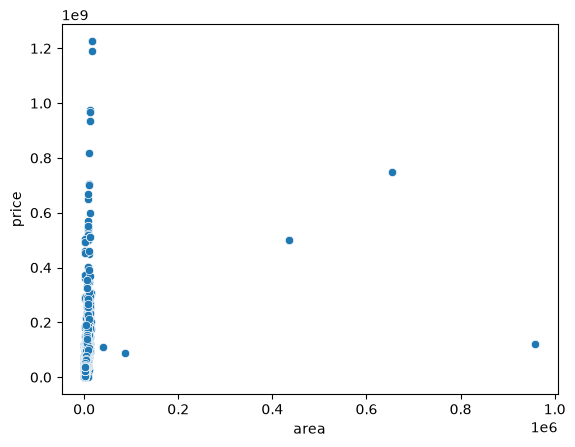

Area per square foot does not affect largly on the price


In [22]:
# 6.How does area (sqft) impact property price?
sns.scatterplot(x="area",y="price",data=df)
plt.show()

print("Area per square foot does not affect largly on the price")

In [33]:
# 7. Which BHK configuration is the most expensive on average?
bhk_config_avg=df.groupby("bhk_count")["rate_per_sqft"].mean().idxmax()
print(f"{bhk_config_avg} is the most expensive configuration on an average")

114.0 is the most expensive configuration on an average


In [34]:
# 8. Which property type (Apartment, Floor, Plot) is the costliest?
property_type_max=df.groupby("flat_type")["rate_per_sqft"].mean().idxmax()
print(f"{property_type_max} is the most costliest property type")

villa is the most costliest property type


In [35]:
# 9. Do certain builders or companies consistently price higher?
builders_high=df.groupby("company_name")["rate_per_sqft"].mean().sort_values(ascending=False).head(5)
for builders in builders_high.index:
    print(builders)

Camelliaass
Cameliaas
Tulip
Prom
Magnoliaass


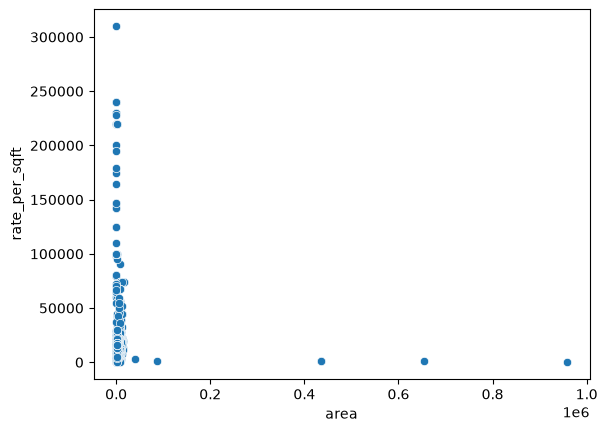

No larger homes do not always more expensive per square foot


In [37]:
# 10. Are larger homes always more expensive per square foot?
sns.scatterplot(x="area",y="rate_per_sqft",data=df)
plt.show()

print("No larger homes do not always more expensive per square foot")